# DH Refined Diagnostics — 20260722_v1985 (honest-mean tail variants, packed cells run)

Refined screening of the structure-C decoupled-covariate grid: 786,432 cells =
16 s1_cov x 16 s2_cov x 3 thresholds {0.70, 0.85, 0.95} x (s2 ⊇ bulk ⊇ tail chains) x
2 bulk exposure modes x (8 honest-mean tail families x 4 exposure modes).
Everything runs off `dh_results.parquet` (metrics only — the run skipped model
predictions); full ranking stack takes < 1 min at this scale.

Mirrors `notebooks/20260714_v1985/dh_refined_diagnostics.ipynb`; changes: lib
screening import (no reports shim), 20260722 paths, RATIO_BOUNDS reset to this
cycle's intermediate gate (TUNE).

In [21]:
%load_ext autoreload
%autoreload 2

from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from idd_tc_mortality.select.model_query import ModelQuery
from idd_tc_mortality.select.model_selection import (
    CONFIG_COLS,
    DEFAULT_METRICS,
    CALIBRATION_METRICS,
    prepare_rankings_df,
    borda_rank,
    pareto_frontier,
    topsis_rank,
    pairwise_dominance_summary,
    cluster_configurations,
    winner_profile,
    kendall_tau_heatmap,
    prune_redundant_metrics
)
from idd_tc_mortality.viz.stage_plots import StagePlotter

from idd_tc_mortality.viz import screening as H

%matplotlib inline
plt.rcParams['figure.dpi'] = 100
pd.options.display.max_columns = 80
pd.options.display.width = 160

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


## Paths

Edit the dates to point at the refined run you want to inspect.

In [22]:
ROOT      = Path('/mnt/team/idd/pub/idd_tc_mortality')
EVAL_DATE = '20260722_v1985_refined'   # packed cells run (honest-mean tails)
DATA_DATE = '20260722_v1985'

RESULTS_PATH = ROOT / '02-evaluate' / EVAL_DATE / 'dh_results.parquet'
EVAL_DIR     = ROOT / '02-evaluate' / EVAL_DATE
DATA_PATH    = ROOT / '00-data'     / DATA_DATE / 'input.parquet'
SPECS_PATH   = ROOT / '01-refined'  / 'tailvariants' / 'refined_is_specs.json'  # 1,696 IS specs, shared by both vintages (reference only)

for p in (RESULTS_PATH, EVAL_DIR, DATA_PATH):
    assert p.exists(), f'Missing: {p}'
print('All paths resolve.')


All paths resolve.


## Load

In [23]:
dh_results = pd.read_parquet(RESULTS_PATH)
data       = pd.read_parquet(DATA_PATH)

print(f'dh_results : {dh_results.shape[0]:,} rows × {dh_results.shape[1]} cols')
print(f'training   : {data.shape[0]:,} rows × {data.shape[1]} cols')
print(f'fold_tags  : {dh_results["fold_tag"].value_counts().to_dict()}')
print(f'configs    : {dh_results.groupby(CONFIG_COLS, dropna=False).ngroups:,} unique')
print(f'thresholds : {sorted(dh_results["threshold_quantile"].unique())}')

dh_results : 4,672,457 rows × 252 cols
training   : 3,024 rows × 14 cols
fold_tags  : {'insample': 786208, 'oos_seed4': 782741, 'oos_seed2': 779168, 'oos_seed0': 776800, 'oos_seed1': 774841, 'oos_seed3': 772699}
configs    : 786,208 unique
thresholds : [np.float64(0.7), np.float64(0.85), np.float64(0.95)]


## Build the rankings dataframe

`prepare_rankings_df(..., subset='oos')` gives one row per config with OOS
metrics averaged across seeds. This is the canonical input to all ranking
methods below.

Then we cull: drop configs with any non-finite OOS metric (failed folds)
and configs outside the calibration gate. Tighten or loosen the cull as
needed.

In [24]:
df_oos = prepare_rankings_df(dh_results, subset='oos')
print(f'{len(df_oos):,} configurations before any cull')

784,544 configurations before any cull


In [25]:
print(f'Before cull: {len(df_oos):,} configs')

# Drop configs with any non-finite OOS metric (failed folds).
oos_numeric = [c for c in df_oos.columns
               if c.endswith('_oos') and pd.api.types.is_numeric_dtype(df_oos[c])]
finite_mask = np.isfinite(df_oos[oos_numeric].to_numpy()).all(axis=1)
n_failed = int((~finite_mask).sum())
df_oos = df_oos[finite_mask].copy()
print(f'After non-finite cull: {len(df_oos):,} configs ({n_failed:,} dropped as failures)')

# Calibration gate — TUNE on the ratio distribution above. Intermediate
# stage used (0.1, 2.0) on the honest-mean families; the 20260714
# post-2000 cycle used an asymmetric (0.05, 1.1).
RATIO_BOUNDS = (0.1, 2.0)   # TUNE
df_oos = df_oos[df_oos['full_pred_obs_ratio_oos'].between(*RATIO_BOUNDS)].copy()
print(f'After calibration gate [{RATIO_BOUNDS[0]}, {RATIO_BOUNDS[1]}]: '
      f'{len(df_oos):,} configs')

print('\nPost-cull count per threshold:')
print(df_oos['threshold_quantile'].value_counts().sort_index().to_string())

Before cull: 784,544 configs
After non-finite cull: 784,536 configs (8 dropped as failures)
After calibration gate [0.1, 2.0]: 584,632 configs

Post-cull count per threshold:
threshold_quantile
0.70    151601
0.85    185019
0.95    248012


### Convergence gate — N/A for the re-fit pipeline

The 20260517 version scanned per-component `{component_id}.json` sidecars in the
fit directory for an IRLS/optimiser `converged` flag. The re-fit-in-evaluate
pipeline has **no fit stage and writes no sidecars** — each component is re-fit
in-memory by the evaluate worker, and convergence is not persisted to
`dh_results.parquet`. So this gate is dropped; `df_oos` after the calibration gate
above is the final candidate pool.


## Per-rule winner trajectories

Same diagnostic as the preliminary qmd's Threshold section, on the refined
survivor pool. For each threshold, six configs are identified — the one
that wins at coverage level 1, 5, 10, 15, 20 (argmax of
`full_coverage_rate_L_oos`), and the one that wins on the mean across all
20 levels — and their full 1..20 trajectories are plotted. Each level-winner
gets a dot at the level where it was picked.

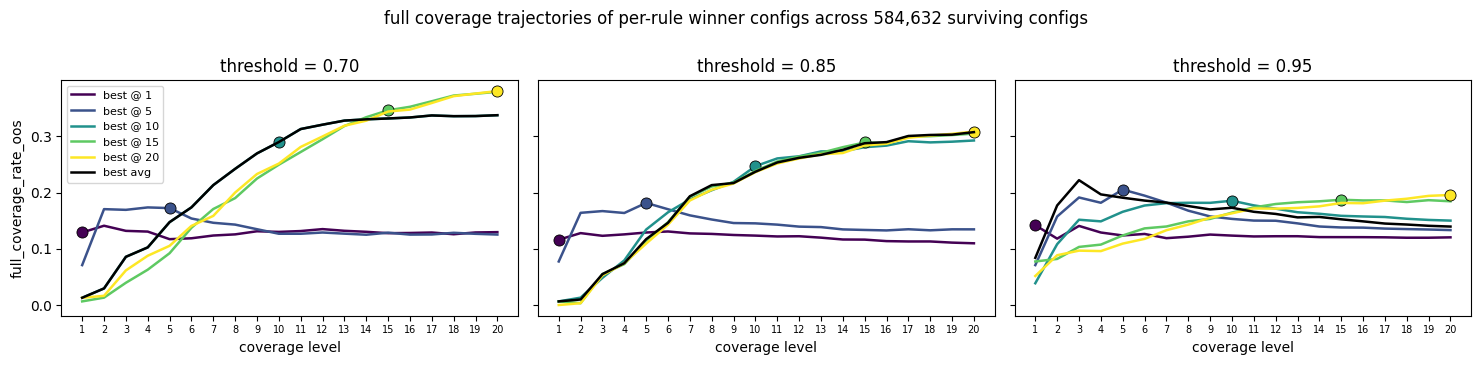


Winner configs per (threshold, rule):
 threshold      rule s1_family s1_exposure_mode                                                                s1_cov s2_family s2_exposure_mode                                                                 s2_cov  bulk_family bulk_exposure_mode                                                                bulk_cov        tail_family tail_exposure_mode                                                                tail_cov
      0.70  best @ 1     logit             free  {"basin": true, "is_island": true, "sdi": true, "wind_speed": false}     logit             free {"basin": false, "is_island": false, "sdi": true, "wind_speed": false} scaled_logit               free  {"basin": false, "is_island": false, "sdi": true, "wind_speed": false}  log_logistic_cens               free  {"basin": false, "is_island": false, "sdi": true, "wind_speed": false}
      0.70  best @ 5     logit             free  {"basin": true, "is_island": true, "sdi": true, "win

In [26]:
winner_records = H.threshold_winner_panels(df_oos)
plt.show()

print('\nWinner configs per (threshold, rule):')
print(winner_records.to_string(index=False))

## Pick your own metrics

The 13-metric `DEFAULT_METRICS` is just a starting point. Edit the dict
below — comment / uncomment lines — to define the set used downstream.
Both the Kendall heatmap and the ranking step use whatever you set as
`metrics_present` and `calib_present` here.

Direction:
- `'lower'`  → smaller is better
- `'higher'` → larger is better
- `'calib'`  → closer to 1.0 is better (handled separately by the ranking API)

In [27]:
metrics_to_use = {
    # ---- S1 (binary: P(deaths >= 1)) ----
    # 's1_auroc_oos':                  'higher',
    # 's1_brier_oos':                'lower',
    # 's1_fpr_oos':                  'lower',
    # 's1_fnr_oos':                  'lower',

    # ---- S2 (binary: P(rate >= thresh | deaths >= 1)) ----
    # 's2_auroc_oos':                  'higher',
    # 's2_brier_oos':                'lower',

    # ---- Bulk (regression on rate < thresh) ----
    # 'bulk_mae_rate_oos':             'lower',
    # 'bulk_rmse_rate_oos':          'lower',
    # 'bulk_cor_rate_oos':           'higher',

    # ---- Tail (regression on rate >= thresh) ----
    'tail_mae_rate_oos':             'lower',
    'tail_rmse_rate_oos':          'lower',
    'tail_cor_rate_oos':           'higher',

    # ---- Full (unconditional E[rate], applies to every row) ----
    'full_mae_rate_oos':             'lower',
    'full_rmse_rate_oos':            'lower',
    'full_cor_rate_oos':             'higher',
    'full_zero_acc_oos':             'higher',
    'full_pred_obs_ratio_oos':       'calib',
    'full_coverage_rate_10_oos':     'higher',
    'full_coverage_count_10_oos':     'higher',

    # ---- Forward (stage-conditional aggregate) ----
    'fwd_mae_rate_oos':              'lower',
    'fwd_pred_obs_ratio_oos':        'calib',
    'fwd_coverage_rate_10_oos':      'higher',
    'fwd_coverage_count_10_oos':      'higher',
}

calib_present   = [k for k, v in metrics_to_use.items()
                   if v == 'calib' and k in df_oos.columns]
# metrics_present = {k: v for k, v in metrics_to_use.items()
#                    if v != 'calib' and k in df_oos.columns}
metrics_present = {k: v for k, v in metrics_to_use.items()
                   if k in df_oos.columns}

print(f'Active rank metrics ({len(metrics_present)}):')
for m, d in metrics_present.items():
    print(f'  {m:35s}  {d}')
print(f'\nActive calibration metrics ({len(calib_present)}):')
for c in calib_present:
    print(f'  {c}  (closer to 1.0)')

missing = [k for k in metrics_to_use if k not in df_oos.columns]
if missing:
    print(f'\n[note] {len(missing)} requested metrics not in df_oos (skipped): {missing}')

Active rank metrics (14):
  tail_mae_rate_oos                    lower
  tail_rmse_rate_oos                   lower
  tail_cor_rate_oos                    higher
  full_mae_rate_oos                    lower
  full_rmse_rate_oos                   lower
  full_cor_rate_oos                    higher
  full_zero_acc_oos                    higher
  full_pred_obs_ratio_oos              calib
  full_coverage_rate_10_oos            higher
  full_coverage_count_10_oos           higher
  fwd_mae_rate_oos                     lower
  fwd_pred_obs_ratio_oos               calib
  fwd_coverage_rate_10_oos             higher
  fwd_coverage_count_10_oos            higher

Active calibration metrics (2):
  full_pred_obs_ratio_oos  (closer to 1.0)
  fwd_pred_obs_ratio_oos  (closer to 1.0)


## Intermediate culling

In [28]:
df_oos_intermediate = df_oos.copy()

print(f'Computing rank correlations on {len(df_oos_intermediate):,} configs × '
      f'{len(metrics_present)} metrics')
tau_df = kendall_tau_heatmap(df_oos_intermediate, metrics_present, calib_present, plot=False, verbose = False)
intermediate_metrics_present, prune_log = prune_redundant_metrics(tau_df, metrics_present, threshold=0.7)
tau_df = kendall_tau_heatmap(df_oos_intermediate, intermediate_metrics_present, calib_present, plot=False, verbose = False)
pre_topsis, _ = topsis_rank(df_oos_intermediate, intermediate_metrics_present, calib_present, verbose=False)

Computing rank correlations on 584,632 configs × 14 metrics
step 1: |τ|=0.747  tail_mae_rate_oos (0.157) vs tail_rmse_rate_oos (0.110)  → drop tail_mae_rate_oos


In [29]:
# Then the pre-Kendall cull cell:
CULL_PCT = 50   # TUNE: drop the bottom X% by preliminary TOPSIS score

cut = pre_topsis['topsis_score'].quantile(CULL_PCT / 100)
df_oos_cull_bad = (pre_topsis[pre_topsis['topsis_score'] > cut]
          .drop(columns=['topsis_score', 'topsis_rank'])
          .copy())
print(f'kept {len(df_oos_cull_bad):,} of {len(df_oos_intermediate):,} configs '
      f'(score > {cut:.3f} = {CULL_PCT}th pct)')

print(f'Computing rank correlations on {len(df_oos_cull_bad):,} configs × '
      f'{len(metrics_present)} metrics')
tau_df = kendall_tau_heatmap(df_oos_cull_bad, metrics_present, calib_present, plot=False, verbose = False)
final_metrics_present, prune_log = prune_redundant_metrics(tau_df, metrics_present, threshold=0.7)
tau_df = kendall_tau_heatmap(df_oos_cull_bad, final_metrics_present, calib_present, plot=False, verbose = False)

topsis_df, _   = topsis_rank(df_oos_cull_bad, final_metrics_present, calib_present, verbose=False)
summary_quality = (topsis_df
    .groupby(['tail_family'])
    .agg(
        n_configs=('topsis_rank', 'count'),
        min_rank=('topsis_rank', 'min'),
        max_score=('topsis_score', 'max'),
    )
    .reset_index()
    .sort_values('min_rank')
)
intermediate_df = summary_quality.head(5)
print(intermediate_df.to_string())
# Then the pre-Kendall cull cell:
df_oos_final = df_oos_cull_bad[df_oos_cull_bad['tail_family'].isin(intermediate_df['tail_family'].unique())]
print(f'kept {len(df_oos_final):,} of {len(df_oos_cull_bad):,} configs')

print(f'Computing rank correlations on {len(df_oos_final):,} configs × '
      f'{len(metrics_present)} metrics')
tau_df = kendall_tau_heatmap(df_oos_final, metrics_present, calib_present, plot=False, verbose = False)
final_metrics_present, prune_log = prune_redundant_metrics(tau_df, metrics_present, threshold=0.7)
tau_df = kendall_tau_heatmap(df_oos_final, final_metrics_present, calib_present, plot=False, verbose = False)

topsis_df, _   = topsis_rank(df_oos_final, final_metrics_present, calib_present, verbose=False)
summary_quality = (topsis_df
    .groupby(['threshold_quantile', 'tail_family'])
    .agg(
        n_configs=('topsis_rank', 'count'),
        min_rank=('topsis_rank', 'min'),
        max_score=('topsis_score', 'max'),
    )
    .reset_index()
    .sort_values('min_rank')
)
winner_df = summary_quality.head(10)
print(winner_df.to_string())

kept 292,316 of 584,632 configs (score > 0.597 = 50th pct)
Computing rank correlations on 292,316 configs × 14 metrics
step 1: |τ|=0.759  full_rmse_rate_oos (0.379) vs full_cor_rate_oos (0.421)  → drop full_cor_rate_oos
step 2: |τ|=0.730  tail_mae_rate_oos (0.174) vs tail_rmse_rate_oos (0.104)  → drop tail_mae_rate_oos
          tail_family  n_configs  min_rank  max_score
0               gamma      39778       1.0   0.719965
4  log_logistic_trunc      48154     164.0   0.704537
5           lognormal      26918     800.0   0.690371
2           gpd_trunc      38479    1512.0   0.683054
3   log_logistic_cens      35170    3195.0   0.675072
kept 188,499 of 292,316 configs
Computing rank correlations on 188,499 configs × 14 metrics
step 1: |τ|=0.731  full_rmse_rate_oos (0.390) vs full_cor_rate_oos (0.456)  → drop full_cor_rate_oos
step 2: |τ|=0.727  full_zero_acc_oos (0.388) vs fwd_coverage_rate_10_oos (0.439)  → drop fwd_coverage_rate_10_oos
   threshold_quantile         tail_family  n_con

In [30]:
kept_thresholds = winner_df['threshold_quantile'].unique()
kept_tails = winner_df['tail_family'].unique()

In [31]:

final_topsis_df = topsis_df[
    topsis_df['tail_family'].isin(kept_tails)
    & topsis_df['threshold_quantile'].isin(kept_thresholds)].copy()

print('tails:     ', kept_tails)
print('thresholds:', kept_thresholds)
print(f'cross = {len(kept_tails)} x {len(kept_thresholds)} = '
      f'{len(kept_tails) * len(kept_thresholds)} groups; '
      f'{len(final_topsis_df):,} shortlisted configs pass the axis filter')


tails:      <ArrowStringArray>
['gamma', 'lognormal', 'log_logistic_trunc', 'gpd_trunc', 'log_logistic_cens']
Length: 5, dtype: str
thresholds: [0.7  0.85]
cross = 5 x 2 = 10 groups; 127,813 shortlisted configs pass the axis filter


In [32]:
import json
def decode_cov_columns(df):
    for stage in ['s1', 's2', 'bulk', 'tail']:
        col = f'{stage}_cov'
        for cov in ['basin', 'is_island', 'sdi', 'wind_speed']:
            df[f'{stage}_{cov}'] = df[col].apply(
                lambda x: (x if isinstance(x, dict) else json.loads(x)).get(cov, False)
            )
    return df

final_topsis_df = decode_cov_columns(final_topsis_df)

for stage in ['s1', 's2', 'bulk', 'tail']:
    covs = ['basin', 'is_island', 'sdi', 'wind_speed']
    final_topsis_df[f'{stage}_pattern'] = final_topsis_df.apply(
        lambda row: '+'.join(c for c in covs if row[f'{stage}_{c}']), axis=1
    )

In [33]:
for tail in kept_tails:
    print(f'Tail distribution: {tail}')
    for threshold in kept_thresholds:
        print(f'  Threshold: {threshold}')
        group_df = final_topsis_df[(final_topsis_df['tail_family'] == tail) & (final_topsis_df['threshold_quantile'] == threshold)]

        print(group_df[['threshold_quantile', 'tail_family', 'topsis_rank',
                       'bulk_pattern', 'tail_pattern',
                       'tail_exposure_mode',
                       'bulk_exposure_mode']].head(10).to_string(index=False))


Tail distribution: gamma
  Threshold: 0.7
 threshold_quantile tail_family  topsis_rank                   bulk_pattern   tail_pattern tail_exposure_mode bulk_exposure_mode
                0.7       gamma          1.0           basin+sdi+wind_speed sdi+wind_speed        free+weight        free+weight
                0.7       gamma          2.0                 sdi+wind_speed sdi+wind_speed        free+weight               free
                0.7       gamma          3.0           basin+sdi+wind_speed sdi+wind_speed        free+weight               free
                0.7       gamma          4.0                 sdi+wind_speed sdi+wind_speed        free+weight        free+weight
                0.7       gamma          5.0 basin+is_island+sdi+wind_speed sdi+wind_speed        free+weight        free+weight
                0.7       gamma          6.0           basin+sdi+wind_speed sdi+wind_speed        free+weight               free
                0.7       gamma          7.0           

In [34]:
TOP_N = 10

# The 20260714 final-grid cov sets, in your pattern-string convention
baseline = {
    's1':   {'basin+sdi+wind_speed', 'basin+is_island+sdi+wind_speed'},
    's2':   {'basin+sdi+wind_speed', 'basin+is_island+sdi+wind_speed'},
    'bulk': {'sdi', 'basin+sdi', 'sdi+wind_speed', 'basin+sdi+wind_speed',
             'is_island+sdi+wind_speed', 'basin+is_island+sdi+wind_speed'},
    'tail': {'', 'wind_speed', 'sdi', 'is_island+sdi', 'basin+sdi',
             'basin+sdi+wind_speed', 'is_island+sdi+wind_speed',
             'basin+is_island+sdi+wind_speed'},
}

# Cov/exposure unions come from the MERIT groups only — the actual
# winner_df rows, NOT the kept_tails x kept_thresholds cross. Crossed-in
# groups still appear in the final grid (axes are the cross), but their
# junk patterns don't expand the cov lists.
merit_pairs = winner_df[['tail_family', 'threshold_quantile']].drop_duplicates()
tops = (final_topsis_df
    .sort_values('topsis_rank')
    .groupby(['tail_family', 'threshold_quantile'])
    .head(TOP_N)
    .merge(merit_pairs, on=['tail_family', 'threshold_quantile']))
print(f'unions built from {len(merit_pairs)} merit groups '
      f'({tops["tail_family"].nunique()} families x '
      f'{tops["threshold_quantile"].nunique()} thresholds represented)\n')

final_covs = {stage: sorted(baseline[stage] | set(tops[f'{stage}_pattern']))
              for stage in ['s1', 's2', 'bulk', 'tail']}
tail_pairs     = sorted(set(zip(tops['tail_family'], tops['tail_exposure_mode'])))
bulk_exposures = sorted(set(tops['bulk_exposure_mode']))

for stage, pats in final_covs.items():
    print(f'{stage}: {len(pats)} cov sets')
    for p in pats:
        print('   ', p or '(intercept-only)')
from collections import defaultdict
by_fam = defaultdict(list)
for fam, exp in tail_pairs:
    by_fam[fam].append(exp)
print('\ntail (family, exposure) pairs:')
for fam in sorted(by_fam):
    print(f'    {fam}: {", ".join(sorted(by_fam[fam]))}')

print('bulk exposures:', bulk_exposures)

n = (len(kept_thresholds) * len(final_covs['s1']) * len(final_covs['s2'])
     * len(bulk_exposures) * len(final_covs['bulk'])
     * len(tail_pairs) * len(final_covs['tail']))
print(f'\nimplied final grid: {n:,} configs per vintage (20260714 was 4,608)')


unions built from 10 merit groups (5 families x 2 thresholds represented)

s1: 6 cov sets
    basin
    basin+is_island
    basin+is_island+sdi
    basin+is_island+sdi+wind_speed
    basin+sdi
    basin+sdi+wind_speed
s2: 3 cov sets
    basin+is_island+sdi+wind_speed
    basin+sdi+wind_speed
    sdi+wind_speed
bulk: 9 cov sets
    basin+is_island+sdi
    basin+is_island+sdi+wind_speed
    basin+is_island+wind_speed
    basin+sdi
    basin+sdi+wind_speed
    is_island+sdi
    is_island+sdi+wind_speed
    sdi
    sdi+wind_speed
tail: 12 cov sets
    (intercept-only)
    basin+is_island+sdi+wind_speed
    basin+is_island+wind_speed
    basin+sdi
    basin+sdi+wind_speed
    basin+wind_speed
    is_island+sdi
    is_island+sdi+wind_speed
    is_island+wind_speed
    sdi
    sdi+wind_speed
    wind_speed

tail (family, exposure) pairs:
    gamma: free+weight, weight
    gpd_trunc: free+weight
    log_logistic_cens: free+weight
    log_logistic_trunc: free+weight
    lognormal: free+weight, 